<a href="https://colab.research.google.com/github/Minqiulee/training-fb-melco/blob/main/2000_2026_predicting_football_results_with_statistical_modelling_dixon_coles_and_time_weighting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Football Results with Statistical Modelling

 I showed how to build a simple Poisson model to crudely predict the outcome of football (soccer) matches.  I thought I'd show how that basic model could be tweaked and improved in order to achieve revolutionary status.

## Data

We'll initially pull the match results for the Work Cup season from (https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017?resource=download). This link contains >20 years of world cup football data. In this example, we are using 2022 Jan to 2026 May to train the model while, keeping the 2026 Jun for testing.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import poisson,skellam
from scipy.optimize import minimize
from scipy.stats import poisson

##Edwin: this is now a world cup dataset from 2020 Jan to 2026 May, i leave thte 2026 Jun for testing

world_cup = pd.read_csv("/content/formatted_results_2000_2026.csv")
world_cup = world_cup[['HomeTeam','AwayTeam','FTHG','FTAG']]
world_cup = world_cup.rename(columns={'FTHG': 'HomeGoals', 'FTAG': 'AwayGoals'})
world_cup.head()

,HomeTeam,AwayTeam,HomeGoals,AwayGoals
0,Egypt,Togo,2.0,1.0
1,Tunisia,Togo,7.0,0.0
2,Trinidad and Tobago,Canada,0.0,0.0
3,Burkina Faso,Gabon,1.0,1.0
4,Guatemala,Armenia,1.0,1.0


## Basic Poisson Model

Essentially, you treat the number of goals scored by each team as two independent Poisson distributions (henceforth called the Basic Poisson (BP) model). The shape of each distribution is determined by the average number of goals scored by that team. A little reminder on the mathematical definition of the Poisson distribution:

$$
P\left( x \right) = \frac{e^{-\lambda} \lambda ^x }{x!}, \lambda>0
$$

In our case, $\lambda$ represents the team's average or expected goal scoring rate. The Poisson distribution is a decent approximation of a team's scoring frequency. All of the model's discussed here agree on this point; the disagreement centres on how to calculate $\lambda_{home}$ and $\lambda_{away}$.

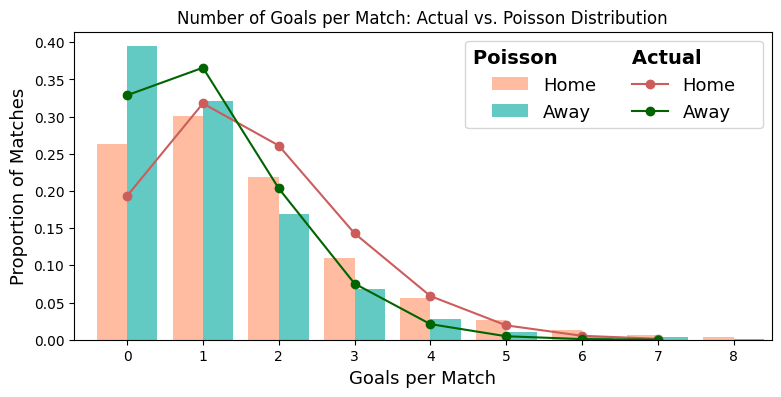

In [ ]:
# mean calculation by selecting numeric columns explicitly
means = world_cup[['HomeGoals', 'AwayGoals']].mean().values
poisson_pred = np.column_stack([[poisson.pmf(i, means[j]) for i in range(8)] for j in range(2)])

fig, ax = plt.subplots(figsize=(9,4))

# Use align='left' or adjust bins to seamlessly align the histogram bars with integers
plt.hist(world_cup[['HomeGoals', 'AwayGoals']].values, bins=np.arange(10)-0.5,
         alpha=0.7, label=['Home', 'Away'], density=True, color=["#FFA07A", "#20B2AA"])

# Add lines for the Poisson distributions centered at integer values (0 to 7)
pois1, = plt.plot(range(8), poisson_pred[:,0],
                  linestyle='-', marker='o', label="Home", color='#CD5C5C')
pois2, = plt.plot(range(8), poisson_pred[:,1],
                  linestyle='-', marker='o', label="Away", color='#006400')

leg = plt.legend(loc='upper right', fontsize=13, ncol=2)
leg.set_title("Poisson           Actual        ", prop={'size':'14', 'weight':'bold'})

# Aligning x-ticks perfectly with goals integers
plt.xticks(range(9))
plt.xlim(-0.7, 8.5)
plt.xlabel("Goals per Match", size=13)
plt.ylabel("Proportion of Matches", size=13)
plt.title("Number of Goals per Match: Actual vs. Poisson Distribution")

plt.show()

We can formulate the model in mathematical terms:
$$
P\left(X_{i,j} = x, Y_{j,i} = y \right) = \frac{e^{-\lambda} \lambda^x }{x!} \frac{e^{-\mu} \mu^y }{y!}
\\ \text{where } \quad \lambda = \alpha_i \beta_j \gamma \quad \mu = \alpha_j \beta_i
$$

In this equation, $i$ and $j$ refer to the home and away teams, respectively; $\alpha$ and $\beta$ denote each team's attack and defensive strength, respectively, while $\gamma$ represents the home advantage factor. So, we need to calculate $\alpha$ and $\beta$ for each team, as well as $\gamma$ (the home field advantage term- it's the same value for every team).

Since World Cup does not have 'home' advantage for most of the team, we are going to neglect the $\gamma$.



In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Clean the initial dataset
world_cup['HomeGoals'] = pd.to_numeric(world_cup['HomeGoals'], errors='coerce')
world_cup['AwayGoals'] = pd.to_numeric(world_cup['AwayGoals'], errors='coerce')
world_cup = world_cup.dropna(subset=['HomeGoals', 'AwayGoals', 'HomeTeam', 'AwayTeam'])

# 2. Reshape the DataFrame
goal_model_data = pd.concat([
    world_cup[['HomeTeam', 'AwayTeam', 'HomeGoals']].assign(home=1).rename(
        columns={'HomeTeam': 'team', 'AwayTeam': 'opponent', 'HomeGoals': 'goals'}),
    world_cup[['AwayTeam', 'HomeTeam', 'AwayGoals']].assign(home=0).rename(
        columns={'AwayTeam': 'team', 'HomeTeam': 'opponent', 'AwayGoals': 'goals'})
])

# Ensure goals are integers and drop any remaining NaN/Inf values
goal_model_data['goals'] = goal_model_data['goals'].astype(int)
goal_model_data = goal_model_data[np.isfinite(goal_model_data['goals'])]

# Drop teams with too few matches (prevents perfect separation)
# Teams with 1 or 2 matches can easily cause the exponent to overflow
team_counts = goal_model_data['team'].value_counts()
valid_teams = team_counts[team_counts >= 3].index
goal_model_data = goal_model_data[goal_model_data['team'].isin(valid_teams) & goal_model_data['opponent'].isin(valid_teams)]

# Define the categorical formula
formula = "goals ~ home + C(team) + C(opponent)"

# Use a robust optimization technique to handle convergence safely
try:
    # Attempt regular fitting
    poisson_model = smf.glm(formula=formula, data=goal_model_data, family=sm.families.Poisson()).fit()
except ValueError:
    print("Standard solver failed due to mathematical instability. Switching to regularized fit...")
    # fit_regularized applies a tiny penalty to prevent coefficients from sliding to infinity
    poisson_model = smf.glm(formula=formula, data=goal_model_data, family=sm.families.Poisson()).fit_regularized(alpha=1e-4)

# Print the summary results
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                50398
Model:                            GLM   Df Residuals:                    49790
Model Family:                 Poisson   Df Model:                          607
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -70722.
Date:                Thu, 25 Jun 2026   Deviance:                       57351.
Time:                        09:40:52   Pearson chi2:                 5.22e+04
No. Iterations:                    22   Pseudo R-squ. (CS):             0.3999
Covariance Type:            nonrobust                                         
                                                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------

In [ ]:
poisson_model.predict(pd.DataFrame(data={'team': 'Argentina', 'opponent': 'Canada',
                                       'home':1},index=[1]))

,0
1,2.588012


In [ ]:
poisson_model.predict(pd.DataFrame(data={'team': 'Canada', 'opponent': 'Argentina',
                                       'home':0},index=[1]))

,0
1,0.542965


As an example, Argentina (playing at home) would be expected to score 2.58 goals against Canada, while their opponents would get about 0.48 goals on average (I'm using the terms average and expected interchangeably). As each team is treated independently, we can construct a match score probability matrix.

In [ ]:
def simulate_match(foot_model, homeTeam, awayTeam, max_goals=10):
    home_goals_avg = foot_model.predict(pd.DataFrame(data={'team': homeTeam,
                                                            'opponent': awayTeam,'home':1},
                                                      index=[1])).values[0]
    away_goals_avg = foot_model.predict(pd.DataFrame(data={'team': awayTeam,
                                                            'opponent': homeTeam,'home':0},
                                                      index=[1])).values[0]
    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals+1)] for team_avg in [home_goals_avg, away_goals_avg]]
    return(np.outer(np.array(team_pred[0]), np.array(team_pred[1])))
ars_sou = simulate_match(poisson_model, 'Argentina', 'Canada', max_goals=10)
print(ars_sou[0:5, 0:5])

[[0.05630376 0.03057098 0.00829949 0.00150211 0.0002039 ]
 [0.13141459 0.07135354 0.01937124 0.00350597 0.0004759 ]
 [0.15336273 0.08327062 0.02260652 0.00409152 0.00055539]
 [0.11931768 0.06478534 0.01758809 0.00318324 0.0004321 ]
 [0.06962273 0.03780271 0.01026278 0.00185744 0.00025213]]


In [ ]:
from matplotlib.colors import ListedColormap

def matrix_gif(matrix, colour_matrix, colour_map, subtitle="", heatmap=False, alpha=0.8):
    fig, ax1 = plt.subplots(1, figsize=(5,5))
    if heatmap:
        ax1.matshow(matrix, alpha=alpha)
    else:
        ax1.matshow(colour_matrix, cmap=colour_map, alpha=alpha)
    ax1.tick_params(axis=u'both', which=u'both',length=0)
    ax1.grid(which='major', axis='both', linestyle='')
    ax1.set_xlabel('Away Team Goals', fontsize=12)
    ax1.set_ylabel('Home Team Goals', fontsize=12)
    ax1.xaxis.set_label_position('top')
    nrows, ncols = matrix.shape
    for i in range(nrows):
        for j in range(ncols):
            c = matrix[i][j]
            ax1.text(j, i, str(round(c,4)), va='center', ha='center', size=13)
    plt.figtext(0.5, 0.05, subtitle, horizontalalignment='center',
                fontsize=14, multialignment='left', fontweight='bold')
    return fig

cmap = ListedColormap(['w', '#04f5ff', '#00ff85', '#e90052'])
matrix = simulate_match(poisson_model, 'Argentina', 'Canada', max_goals=5)
matn = len(matrix)
matrix_gif(matrix, matrix, ListedColormap(['w']), heatmap=True,
           alpha=0.6, subtitle="Match Score Probability Matrix").savefig("match_matrix_0.png")
plt.close()
for t,(mat,colour,subtitle) in enumerate(zip([np.zeros((matn, matn)), np.tril(np.ones((matn,matn)),-1),
                            np.triu(np.ones((matn,matn))*2,1), np.diag([3]*matn),
                                             np.array([0 if i+j<3 else 1 for i in range(matn) for j in range(matn)]).reshape(matn,matn)],
                          ['w', '#04f5ff', '#00ff85', '#e90052','#EAF205'],
                                   ['Match Score Probability Matrix', 'Home Win', 'Away Win', 'Draw', 'Over 2.5 goals'])):
    matrix_gif(matrix, mat, ListedColormap(['w'] + [colour]), heatmap=False,
               alpha=0.6, subtitle=subtitle).savefig("match_matrix_{}.png".format(t+1))
    plt.close()

![match_score_probability_matrix](https://github.com/dashee87/dashee87.github.io/blob/master/images/match_matrix.gif?raw=true)

In [ ]:
# 1. Generate the probability matrix
matrix = simulate_match(poisson_model, 'Argentina', 'Portugal', max_goals=5)
matn = len(matrix)

# 2. Define the mathematical masks for each outcome
# Home wins are represented by the lower triangle (excluding the diagonal)
home_win_mask = np.tril(np.ones((matn, matn)), -1)

# Away wins are represented by the upper triangle (excluding the diagonal)
away_win_mask = np.triu(np.ones((matn, matn)), 1)

# Draws are represented by the main diagonal
draw_mask = np.diag([1] * matn)

# Over 2.5 goals are cells where the row index (home goals) + column index (away goals) >= 3
over_2_5_mask = np.array([1 if i + j >= 3 else 0 for i in range(matn) for j in range(matn)]).reshape(matn, matn)


# 3. Calculate probabilities by element-wise multiplication and summing the matrix
prob_home_win = np.sum(matrix * home_win_mask)
prob_away_win = np.sum(matrix * away_win_mask)
prob_draw     = np.sum(matrix * draw_mask)
prob_over_2_5 = np.sum(matrix * over_2_5_mask)


# 4. Display the results
print(f"--- Match Outcome Probabilities ---")
print(f"Home Win Probability: {prob_home_win * 100:.2f}%")
print(f"Away Win Probability: {prob_away_win * 100:.2f}%")
print(f"Draw Probability:     {prob_draw * 100:.2f}%")
print(f"Over 2.5 Goals Prob:  {prob_over_2_5 * 100:.2f}%")

# Sanity Check: Home + Away + Draw should equal ~100% (or slightly less if max_goals is too low)
total_sum = prob_home_win + prob_away_win + prob_draw
print(f"\nTotal Matrix Sum Coverage: {total_sum * 100:.2f}%")

--- Match Outcome Probabilities ---
Home Win Probability: 50.87%
Away Win Probability: 23.27%
Draw Probability:     25.23%
Over 2.5 Goals Prob:  46.34%

Total Matrix Sum Coverage: 99.38%


#Sports Betting/Trading

Unlike traditional bookmakers, on betting exchanges (and Betfair isn’t the only one- it’s just the biggest), you bet against other people (with Betfair taking a commission on winnings). It acts as a sort of stock market for sports events. And, like a stock market, due to the efficient market hypothesis, the prices available at Betfair reflect the true price/odds of those events happening (in theory anyway). Below, I’ve posted a screenshot of the Betfair exchange on Sunday 21st May (a few hours before those matches started).

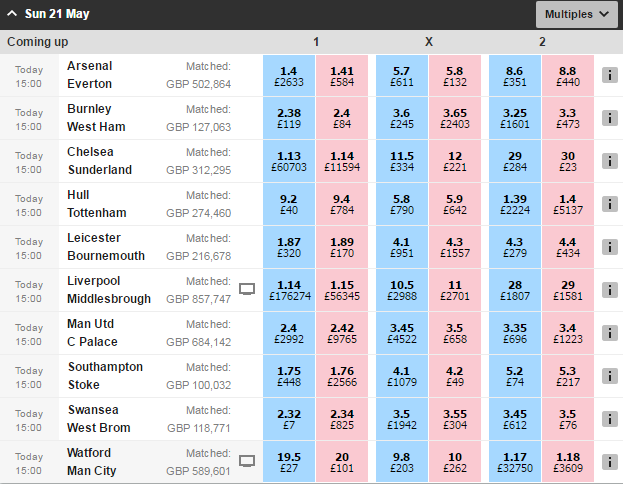

The numbers inside the boxes represent the best available prices and the amount available at those prices. The blue boxes signify back bets (i.e. betting that an event will happen- going long using stock market terminology), while the pink boxes represent lay bets (i.e. betting that something won’t happen- i.e. shorting). For example, if we were to bet £100 on Chelsea to win, we would receive the original amount plus 100*1.13= £13 should they win (of course, we would lose our £100 if they didn’t win). Now, how can we compare these prices to the probabilities returned by our model? Well, decimal odds can be converted to the probabilities quite easily: it’s simply the inverse of the decimal odds. For example, the implied probability of Chelsea winning is 1/1.13 (=0.885- our model put the probability at 0.889). I’m focusing on decimal odds, but you might also be familiar with Moneyline (American) Odds (e.g. +200) and fractional odds (e.g. 2/1). The relationship between decimal odds, moneyline and probability is illustrated in the table below. I’ll stick with decimal odds because the alternatives are either unfamiliar to me (Moneyline) or just stupid (fractional odds).

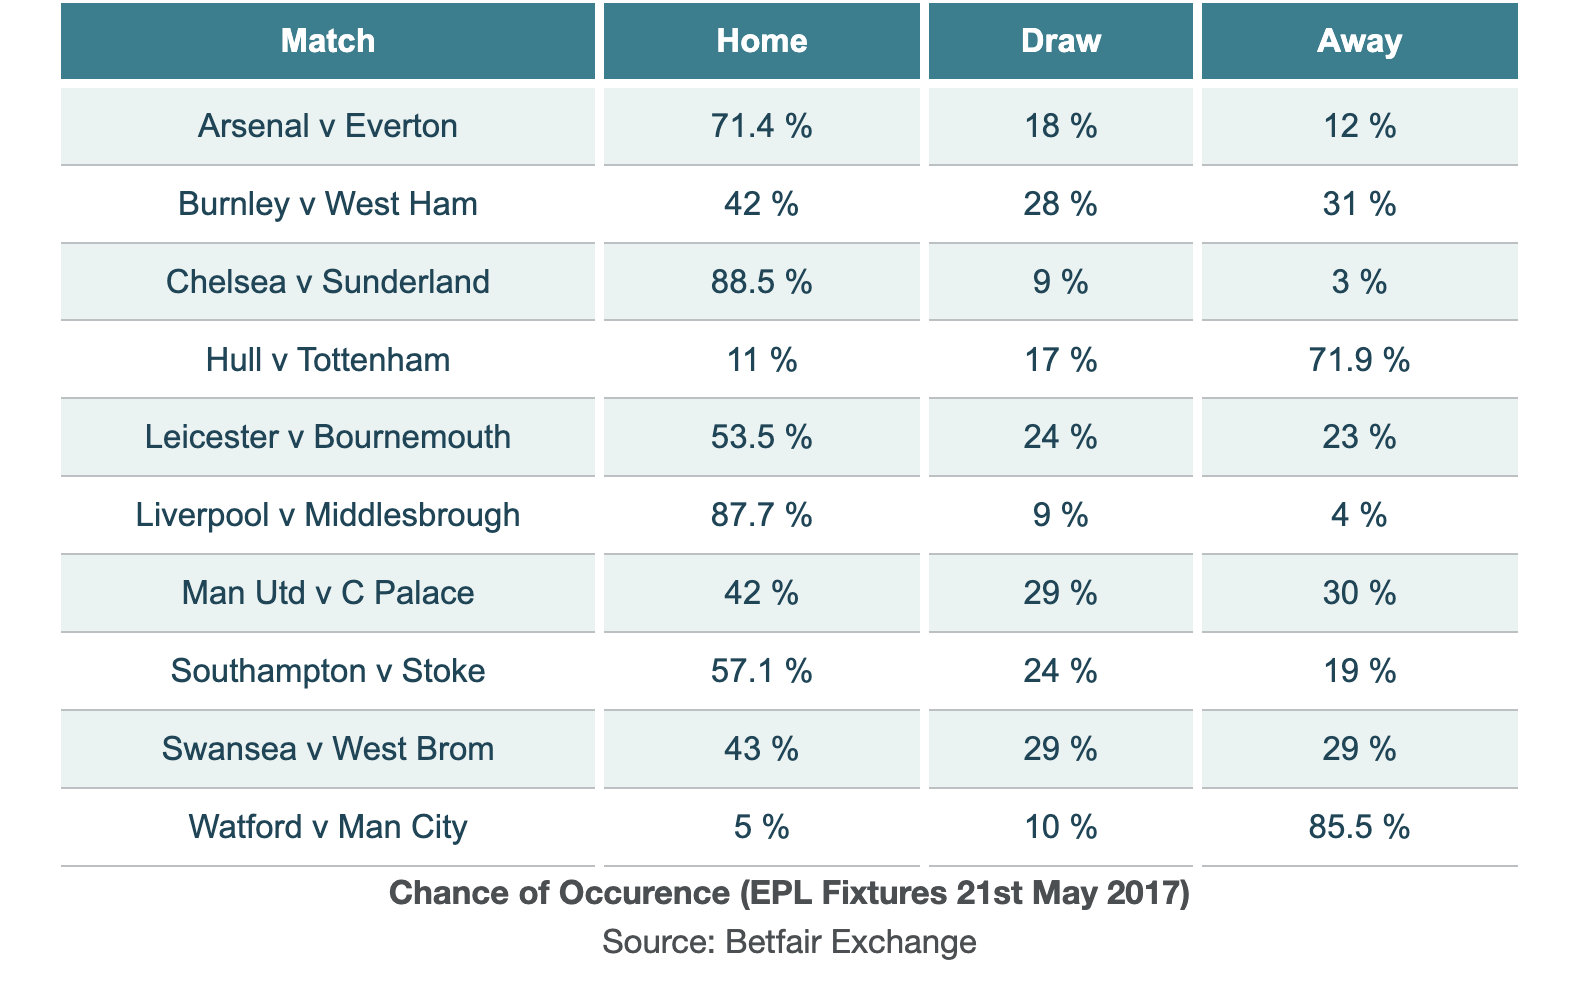

So, we have our model probabilities and (if we trust the exchange) we know the true probabilities of each event happening. Ideally, our model would identify situations the market has underestimated the chances of an event occurring (or not occurring in the case of lay bets). For example, in a simple coin toss game, imagine if you were offered $2 for every $1 wagered (plus your stake), if you guessed correctly. The implied probability is 0.333, but any valid model would return a probability of 0.5. The odds returned by our model and the Betfair exchange are compared in the table below.

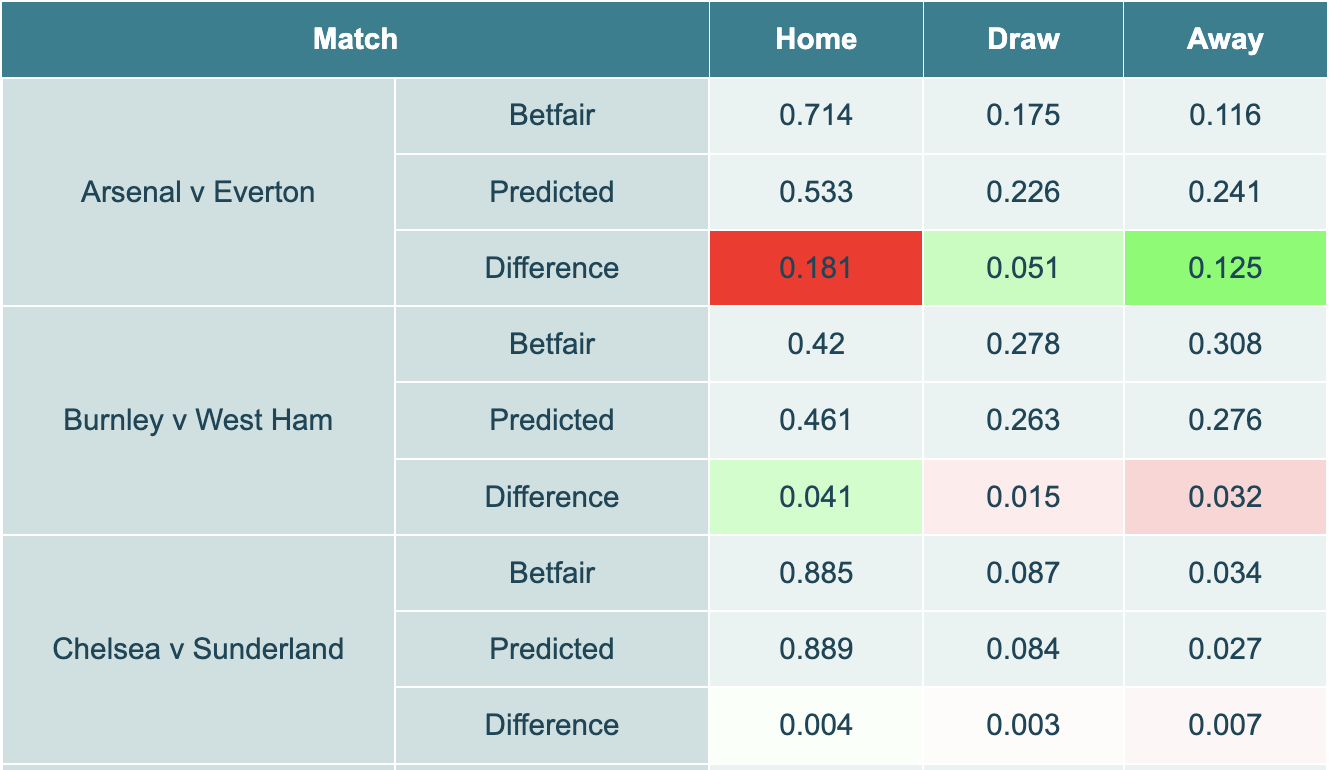